# MÓDULO 34 - Regressão Polinomial
##  Precificação de imoveis 💲🏢

### Contexto

O mercado imobiliário é fortemente influenciado por um conjunto de variáveis que determinam o valor de um imóvel, seja para venda ou locação. Entre esses fatores, destacam-se: Valor do aluguel, Valor do condomínio, Metragem, Número de quartos etc. Cada uma dessas características reflete atributos valorizados por potenciais compradores ou locatários, como conforto, funcionalidade, localização e padrão construtivo. Por exemplo, imóveis com maior metragem e mais vagas de garagem tendem a atrair famílias maiores e, consequentemente, podem apresentar preços mais elevados. 

### 🎯 Objetivo
Desenvolver um modelo de regressão polinomial para prever o preço de imóveis, variando o grau do polinômio e comparando os resultados obtidos. Para isso, a atividade seguirá por 5 passos, conforme descrito abaixo.

1. Importação de bibliotecas e separação dos Dados
2. Modelagem
3. Avaliação dos resultados
4. Definição de conceitos de regularizadores

## 📂 1-Importação de Bibliotecas, Carregamento e Separação dos Dados


In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Leitura dos dados
df = pd.read_csv("/home/akel/PycharmProjects/EBAC/dados/ALUGUEL_MOD12.csv", delimiter=';')
df = df.rename(columns={"N_banheiros": "N_Banheiros"})
df.head()

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_Banheiros,N_Suites,N_Vagas
0,480,295,48,2,2,1,1
1,500,0,50,1,2,1,1
2,500,0,40,1,2,1,1
3,500,36,45,1,2,1,0
4,500,0,30,1,1,0,0


## ⚙️ 2-Modelagem
para esta atividade, foi escrito uma função poly_fit o qual com os dados (X, y) e ajusta uma regressão polinomial de grau N. Ela pode plotar o ajuste (curva polinomial e pontos reais, se solicitado) e retorna: R² e Modelo.


In [2]:
def poly_fit(X,y,N,color=None,show=False,scatter=False):
    """
    Ajusta um modelo de Regressão Polinomial de grau N aos dados de entrada (X, y).
    
    Parâmetros:
    -----------
    X : array-like ou DataFrame
        Variável independente (ex.: metragem).
    y : array-like
        Variável dependente (ex.: valor do aluguel).
    N : int
        Grau do polinômio a ser ajustado.
    color : str, opcional
        Cor da linha de regressão (não utilizado diretamente no código).
    show : bool, opcional
        Se True, plota o gráfico do ajuste polinomial.
    scatter : bool, opcional
        Se True e show=True, plota também os pontos reais de (X,y) no gráfico.

    Saída:
    -------
    r2 : float
        Valor do coeficiente de determinação (R²) do modelo no conjunto de teste.
    model : objeto LinearRegression
        Modelo treinado da regressão polinomial.
    """
    
    poly_features = PolynomialFeatures(degree=N)
    x_poly = poly_features.fit_transform(X)
    
    # Divisão treino/teste
    x_train, x_test, y_train, y_test = train_test_split(x_poly, y, test_size=0.2,random_state=0)
    
    # Treinamento
    model = LinearRegression()
    model.fit(x_train, y_train)
    
    # Estimativa
    y_pred = model.predict(x_test)

    # Ajustes plotagem
    x_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
    x_range_df = pd.DataFrame(x_range, columns=['Metragem']) #transformar para dataframe
    x_range_poly = poly_features.transform(x_range_df)
    y_range_pred = model.predict(x_range_poly)

    # Estatisticas
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)

   # plt.figure(figsize=(12, 15)) 

    if show:
        if scatter :
            plt.scatter(X, y, color='red', alpha=0.5,label='Dados reais')  # Dados reais
        plt.plot(x_range, y_range_pred, label= f'Polinomial grau {N} e R²={r2:.3f}')  # Linha do ajuste
        plt.xlabel('Metragem')
        plt.ylabel('Valor do Aluguel')
        plt.title('Regressão Polinomial')
        plt.legend()
        #print(f'Grau {N} e R²={r2:.4f}')
    return r2,mse,model    

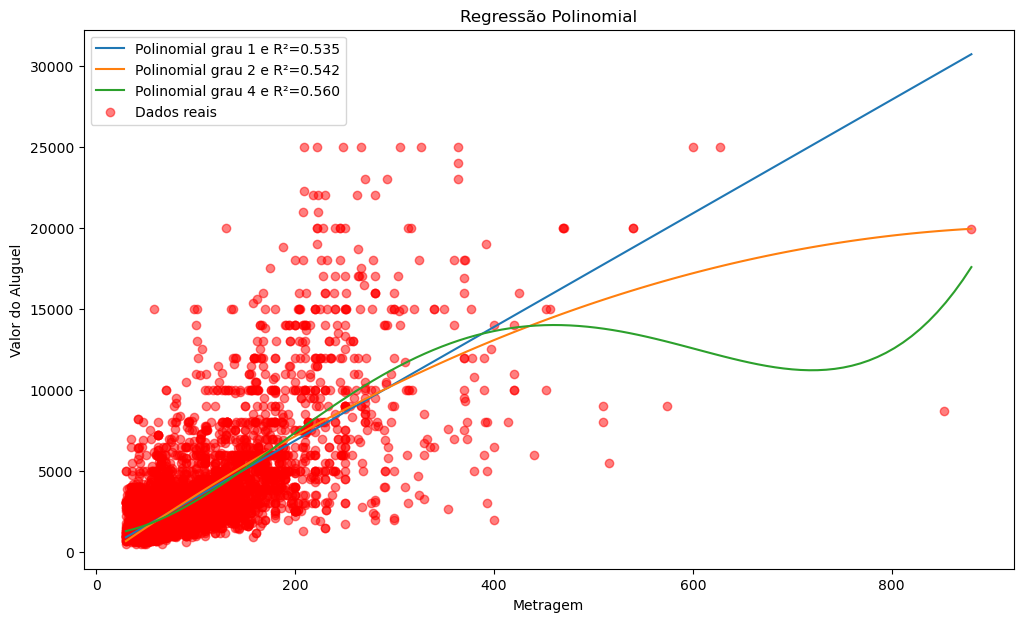

In [3]:
# separação das variavies
y = df['Valor_Aluguel']
X = df[['Metragem']]
plt.figure(figsize=(12, 7)) 
r2_1,mse_1,model_1=poly_fit(X,y,1,color='y',show=True,scatter=True)
r2_2,mse_2,model_2=poly_fit(X,y,2,color='y',show=True)
r2_4,mse_4,model_4=poly_fit(X,y,4,show=True)
r2_5,mse_5,model_5=poly_fit(X,y,5,show=False)
r2_6,mse_6,model_6=poly_fit(X,y,6,show=False)

## 📝 3-Resultados dos ajustes polinomias.
| Grau do Polinômio | R²    | MSE          |
| ----------------- | ----- | ------------ |
| 1 (linear)        | 0.535 | 4310,808.92 |
| 2 (quadrático)    | 0.542 | 4242,097.01 |
| 4      | 0.560 | 4082,376.36 |
| 5      | 0.557 | 4105662.66 |
| 6       | 0.561 | 4068045.355518443 |
Tabela: Ajustes polinomiais.

Para avaliar a complexidade do ajuste, utilizando apenas a variável metragem, obtivemos um valor de R² ligeiramente próximo entre os ajustes de grau 2 (0,535) e grau 4 (0,542), com uma pequena melhoria para o grau 4. Para essa análise, também calculamos o erro médio quadrático (MSE) nas previsões e observamos que ele foi menor para o grau 4.

Além disso, realizamos um ajuste linear para fins de comparação, constatando que esse modelo é inferior aos demais ajustes polinomiais. Observamos ainda que ajustes acima do grau 4 não trouxeram melhorias consistentes. Para os graus 5 e 6, a variação de em R² foi p nulo (~ 0.0001) em relação ao grau 4, e o MSE não apresentou redução significativa. Desta forma, os pequenos ganhos em R² não compensam o aumento da complexidade, pois levar ao overfitting — ou seja, o modelo passa a se ajustar mais ao ruído dos dados do que ao padrão real.


## 📝 4-Ridge,Lasso e Elastic Net

Ambas são técnicas de regularização para regressão (ou modelo de inversão), usadas para criar uma tendência aos ajustes de forma a melhorar sua generalização para bases de dados, desta forma evitando o superajuste ou overfitting dos dados.

No problema de regressão clássico, a matriz de Gram ou informação $A^{T}A$, quando é L.I., a multicolinearidade pode levar a uma solução instável, a alta variância e um número de dados alto comparado ao número de variáveis. Problemas de superajustes precisam ser mitigados.

A técnica Ridge adiciona estabilidade e encolhe os coeficientes, mas não zera parâmetros. Ela funciona aplicando uma penalização L2($\lambda_2\left\| x\right\|_{2}^{2}$), fazendo com que eles se tornem menores $\left(min \left\| Ax-b\right\|_{2}^{2} + \lambda_2\left\| x\right\|_{2}^{2} \right)$, porém sem eliminá-los completamente. Essa abordagem é especialmente útil quando há muitos preditores correlacionados, pois ajuda a reduzir a variância do modelo sem perder informações importantes.

Já a Lasso utiliza uma penalização L1($\lambda_1\left\| x\right\|_{1}$). Assim, quando minimizamos nossa formulação $\left(min \left\| Ax-b\right\|_{2}^{2} + \lambda_1\left\| x\right\|_{1} \right)$, a não diferenciabilidade da norma L1 em zero força alguns coeficientes a serem exatamente zero, o que efetivamente remove variáveis irrelevantes do modelo. Essa característica a torna particularmente vantajosa quando se acredita que apenas um subconjunto das variáveis é realmente relevante para o modelo. Dito de outra forma, ela anula ou ignora colunas que não apresentam vantagens ao ajuste.

Por fim, o Elastic Net combina as vantagens do Ridge e do Lasso, ou seja: $\left(min \left\| Ax-b\right\|_{2}^{2} + \lambda_1\left\| x\right\|_{1}+\lambda_2\left\| x\right\|_{2}^{2} \right)$ mantém a capacidade de seleção de variáveis do Lasso, mas também controla melhor a instabilidade em dados altamente correlacionados, assim como o Ridge. Por isso, é amplamente utilizado em cenários de alta dimensionalidade, onde a relação entre as variáveis pode ser complexa e a seleção de features é crucial para um modelo eficiente.